# NSE2 Lunar Communication Scenario

This notebook focuses exclusively on `Model 2` and runs the full lunar pipeline on every ordered node pair induced by each topology.

- `topology_1.json`
- `topology_2.json`

For each topology, the pipeline computes routing, annotation, and security plans for all ordered pairs before sweeping the Model 2 connectivity target.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
        if (candidate / "modules").is_dir() and (candidate / "pipelines").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root from the current working directory")

SCENARIO_DIR = CURRENT_DIR
if not (SCENARIO_DIR / "contact_plan.json").exists():
    scenario_candidate = REPO_ROOT / "scenarios" / "wisee_nse2_lunar_communication"
    if not scenario_candidate.exists():
        raise RuntimeError("Could not locate the scenario directory wisee_nse2_lunar_communication")
    SCENARIO_DIR = scenario_candidate

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline
from models.plot_utils import set_plot_theme

set_plot_theme()
sns.set_theme(style="whitegrid")

NODE_LABELS = {
    10: "b1cc",
    11: "base1",
    20: "r1cc",
    21: "rover1",
    30: "u1cc",
    31: "user1",
    100: "rcc1",
    110: "gs1",
    120: "relay1",
    200: "rcc2",
    210: "gs2",
    220: "lgw",
    221: "relay2",
}

TOPOLOGY_FILES = {
    "topology_1": SCENARIO_DIR / "topology_1.json",
    "topology_2": SCENARIO_DIR / "topology_2.json",
}

SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}
MODEL_PALETTE = {model.name: color for model, color in SERIES_COLORS.items()}
MAX_ROUTES = 3


def format_pair(pair):
    return f"{pair[0]}->{pair[1]}"


def describe_pair(pair):
    src, dst = pair
    return f"{NODE_LABELS[src]} ({src}) -> {NODE_LABELS[dst]} ({dst})"


def pct_of_max(series):
    max_value = series.max()
    if pd.isna(max_value) or max_value == 0:
        return series * 0
    return 100.0 * series / max_value


def apply_percent_yaxis(grid_or_axes):
    if hasattr(grid_or_axes, "axes"):
        axes = grid_or_axes.axes.flat
    elif hasattr(grid_or_axes, "flat"):
        axes = grid_or_axes.flat
    elif isinstance(grid_or_axes, (list, tuple)):
        axes = grid_or_axes
    else:
        axes = [grid_or_axes]
    for ax in axes:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))


## Full Pipeline Run

The next cells run the full pipeline for every ordered source-destination pair present in each topology. No manual pair subsets are used here.


In [2]:
pipeline = SimulationPipeline()
all_pair_results = {
    topology_name: pipeline.run(
        cp_path=str(SCENARIO_DIR / "contact_plan.json"),
        topology_path=str(topology_path),
        security_models=tuple(SecurityModelType),
        curr_time=0,
        routing_algorithm=CGRYenRouting(max_routes=MAX_ROUTES),
        num_routes=MAX_ROUTES
    )
    for topology_name, topology_path in TOPOLOGY_FILES.items()
}

print(f"Topologies loaded: {len(all_pair_results)}")
list(all_pair_results)


Topologies loaded: 2


['topology_1', 'topology_2']

In [3]:
summary_rows = []
pair_rows = []
for topology_name, sim_result in all_pair_results.items():
    route_count = sum(len(routes) for routes in sim_result.routing.routes_by_pair.values())
    reachable_pairs = sum(1 for routes in sim_result.routing.routes_by_pair.values() if routes)
    total_pairs = len(sim_result.routing.pairs)

    summary_rows.append(
        {
            "topology": topology_name,
            "pairs": total_pairs,
            "reachable_pairs": reachable_pairs,
            "reachable_pairs_pct": 100.0 * reachable_pairs / total_pairs,
            "total_routes": route_count,
            "avg_routes_per_pair": route_count / total_pairs,
        }
    )

    for pair in sim_result.routing.pairs:
        pair_rows.append(
            {
                "topology": topology_name,
                "pair": format_pair(pair),
                "description": describe_pair(pair),
                "candidate_routes": len(sim_result.routing.routes_by_pair[pair]),
            }
        )

summary_df = pd.DataFrame(summary_rows).sort_values("topology").reset_index(drop=True)
pair_df = pd.DataFrame(pair_rows)

display(summary_df)


,topology,pairs,reachable_pairs,reachable_pairs_pct,total_routes,avg_routes_per_pair
0,topology_1,156,156,100.0,464,2.974359
1,topology_2,156,156,100.0,464,2.974359


In [4]:
FOCUS_TOPOLOGY_FOR_PAIRS = "topology_2"

display(pair_df[pair_df["topology"] == FOCUS_TOPOLOGY_FOR_PAIRS].reset_index(drop=True))


,topology,pair,description,candidate_routes
0,topology_2,10->11,b1cc (10) -> base1 (11),3
1,topology_2,10->20,b1cc (10) -> r1cc (20),3
2,topology_2,10->21,b1cc (10) -> rover1 (21),3
3,topology_2,10->30,b1cc (10) -> u1cc (30),3
4,topology_2,10->31,b1cc (10) -> user1 (31),3
...,...,...,...,...
151,topology_2,221->110,relay2 (221) -> gs1 (110),3
152,topology_2,221->120,relay2 (221) -> relay1 (120),3
153,topology_2,221->200,relay2 (221) -> rcc2 (200),3
154,topology_2,221->210,relay2 (221) -> gs2 (210),3


## Model 2: minimize keys for a connectivity target

<table>
<tr>
<td style="width:50%; border:none; vertical-align:top;">

#### Notation
$$
\begin{aligned}
D &: \text{set of evaluated ordered source-destination pairs} \\
P_{sd} &: \text{set of candidate routes for pair } (s,d) \in D \\
P &= \bigcup_{(s,d) \in D} P_{sd} \\
K &: \text{global set of activatable key scopes} \\
K(p) &\subseteq K : \text{key scopes required by route } p \in P \\
\gamma &: \text{target connectivity fraction}
\end{aligned}
$$

$$
\begin{aligned}
x_{sd} &=
\begin{cases}
1 & \text{if pair } (s,d) \text{ is connected} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
y_p &=
\begin{cases}
1 & \text{if route } p \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
z_k &=
\begin{cases}
1 & \text{if key scope } k \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\end{aligned}
$$

</td>
<td style="width:50%; border:none; vertical-align:top;">

#### Model
$$
\begin{aligned}
\min \quad & \sum_{k \in K} z_k \\
\text{s.t.} \quad
& \sum_{(s,d) \in D} x_{sd} \ge \left\lceil \gamma |D| \right\rceil \\
& y_p \le x_{sd} \qquad \forall (s,d) \in D,\ \forall p \in P_{sd} \\
& x_{sd} \le \sum_{p \in P_{sd}} y_p \qquad \forall (s,d) \in D \\
& \sum_{k \in K(p)} z_k \ge |K(p)|\,y_p \qquad \forall p \in P \\
& x_{sd} \in \{0,1\} \qquad \forall (s,d) \in D \\
& y_p \in \{0,1\} \qquad \forall p \in P \\
& z_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
$$

</td>
</tr>
</table>


In [5]:
from models.model2_min_keys import solve_for_security_model as solve_m2

m2_frames = []
traces_m2 = {}
for topology_name, sim_result in all_pair_results.items():
    traces_m2[topology_name] = {}
    for sec_model in SecurityModelType:
        sec_traces, sec_df = solve_m2(sim_result, sec_model)
        sec_df = sec_df.copy()
        sec_df["topology"] = topology_name
        m2_frames.append(sec_df)
        traces_m2[topology_name][sec_model.name] = dict(zip(sec_df["target_connectivity_pct"], sec_traces))

df_m2 = pd.concat(m2_frames, ignore_index=True)
display(df_m2.head())


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2821306
Academic license 2821306 - for non-commercial use only - registered to ra___@unc.edu.ar


,target_connectivity_pct,required_pairs,selected_pairs,selected_routes,selected_keys,total_key_scopes,selected_keys_pct_of_available,achieved_connectivity_pct,model,topology
0,0,0,0,0,0,42,0.000000,0.000000,HOP_BY_HOP,topology_1
1,5,8,8,8,4,42,9.523810,5.128205,HOP_BY_HOP,topology_1
2,10,16,16,16,6,42,14.285714,10.256410,HOP_BY_HOP,topology_1
3,15,24,24,24,7,42,16.666667,15.384615,HOP_BY_HOP,topology_1
4,20,32,32,32,8,42,19.047619,20.512821,HOP_BY_HOP,topology_1


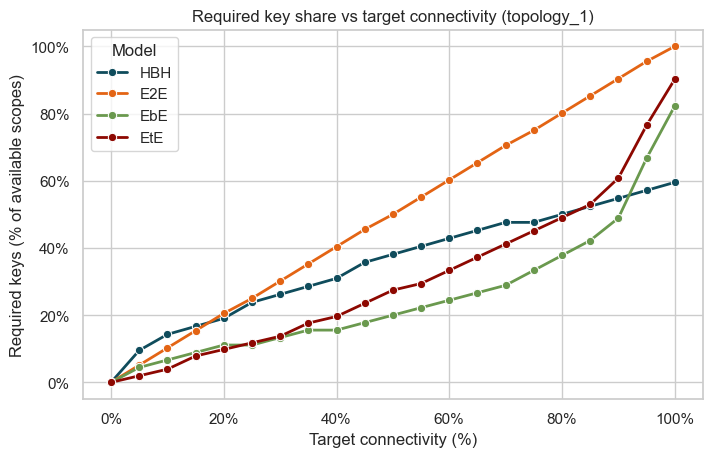

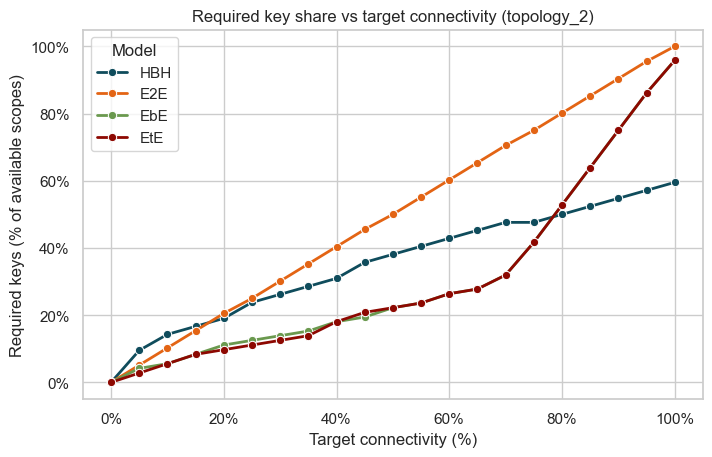

In [9]:
# WiSEE-style plots, one figure per topology
from models.plot_utils import format_model_series, palette_for, plot_metric_curve
from pipelines.route_activation import RouteActivationPlanner

planner = RouteActivationPlanner()
df_m2_wisee_by_topology = {}

for topology_name, result in all_pair_results.items():
    total_scopes_by_model = {
        model.name: len(planner.build_for_model(result.security, model=model).key_scopes)
        for model in SecurityModelType
    }

    topology_df = df_m2[df_m2["topology"] == topology_name].copy()
    topology_df["total_key_scopes"] = topology_df["model"].map(total_scopes_by_model)
    topology_df["selected_keys_pct_of_available"] = (
        100.0 * topology_df["selected_keys"] / topology_df["total_key_scopes"]
    )
    topology_df["model"] = format_model_series(topology_df["model"])
    df_m2_wisee_by_topology[topology_name] = topology_df

    set_plot_theme()
    fig, ax = plt.subplots(figsize=(8, 4.8))

    plot_metric_curve(
        topology_df,
        x="target_connectivity_pct",
        y="selected_keys_pct_of_available",
        ax=ax,
        sort_by="target_connectivity_pct",
        palette=palette_for(topology_df["model"]),
        x_percent_scale=100,
        y_percent_scale=100,
        x_label="Target connectivity (%)",
        y_label="Required keys (% of available scopes)",
        title=f"Required key share vs target connectivity ({topology_name})",
    )

    plt.show()


In [7]:
summary_m2 = (
    df_m2[df_m2["target_connectivity_pct"] == 100.0]
    .sort_values(["topology", "model", "selected_keys", "selected_routes"])
    .drop_duplicates(["topology", "model"])
    [["topology", "model", "selected_keys", "selected_routes", "achieved_connectivity_pct"]]
    .rename(
        columns={
            "selected_keys": "keys_for_100pct",
            "selected_routes": "routes_for_100pct",
            "achieved_connectivity_pct": "achieved_connectivity_pct",
        }
    )
    .reset_index(drop=True)
)

display(summary_m2)


,topology,model,keys_for_100pct,routes_for_100pct,achieved_connectivity_pct
0,topology_1,EDGE_BY_EDGE,37,289,100.0
1,topology_1,EDGE_TO_EDGE,46,370,100.0
2,topology_1,END_TO_END,156,464,100.0
3,topology_1,HOP_BY_HOP,25,156,100.0
4,topology_2,EDGE_BY_EDGE,69,341,100.0
5,topology_2,EDGE_TO_EDGE,69,421,100.0
6,topology_2,END_TO_END,156,464,100.0
7,topology_2,HOP_BY_HOP,25,156,100.0


## Configuration Drilldown

Use this cell to inspect one topology with all ordered pairs and render the Model 2 pair coverage heatmap.


### topology_2 | EDGE_BY_EDGE | target=100.0%

,pair,description,candidate_routes
0,10->11,b1cc (10) -> base1 (11),3
1,10->20,b1cc (10) -> r1cc (20),3
2,10->21,b1cc (10) -> rover1 (21),3
3,10->30,b1cc (10) -> u1cc (30),3
4,10->31,b1cc (10) -> user1 (31),3
...,...,...,...
151,221->110,relay2 (221) -> gs1 (110),3
152,221->120,relay2 (221) -> relay1 (120),3
153,221->200,relay2 (221) -> rcc2 (200),3
154,221->210,relay2 (221) -> gs2 (210),3


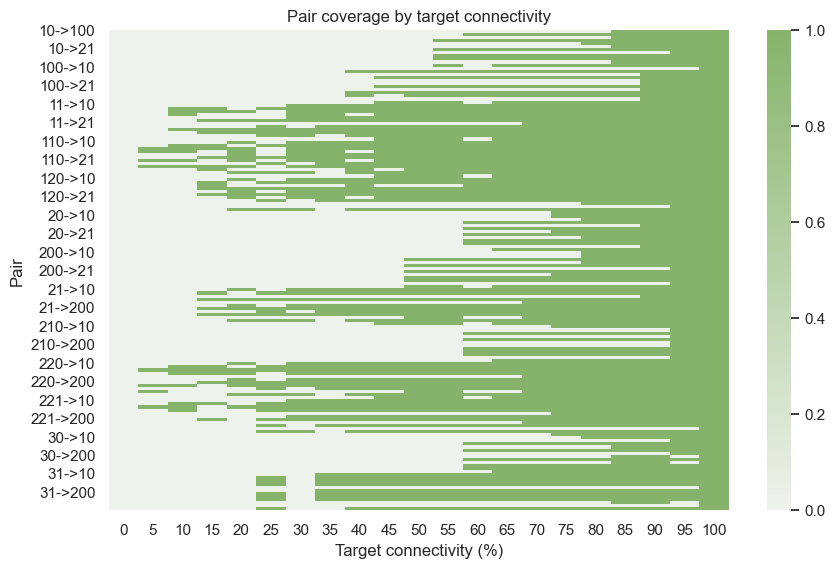

In [8]:
from models.model2_min_keys import plot_connectivity_pair_coverage_heatmap

FOCUS_TOPOLOGY = "topology_2"
FOCUS_MODEL = "EDGE_BY_EDGE"

focus_result = all_pair_results[FOCUS_TOPOLOGY]
available_targets = sorted(traces_m2[FOCUS_TOPOLOGY][FOCUS_MODEL])
FOCUS_CONNECTIVITY = 100.0 if 100.0 in available_targets else available_targets[-1]

focus_pairs = pd.DataFrame(
    {
        "pair": [format_pair(pair) for pair in focus_result.security.pairs],
        "description": [describe_pair(pair) for pair in focus_result.security.pairs],
        "candidate_routes": [len(focus_result.routing.routes_by_pair[pair]) for pair in focus_result.security.pairs],
    }
)
display(Markdown(f"### {FOCUS_TOPOLOGY} | {FOCUS_MODEL} | target={FOCUS_CONNECTIVITY}%"))
display(focus_pairs)

trace = traces_m2[FOCUS_TOPOLOGY][FOCUS_MODEL].get(FOCUS_CONNECTIVITY)
if trace is None:
    print("There is no solution for that topology/model/connectivity combination.")
else:
    plot_connectivity_pair_coverage_heatmap(
        traces_m2[FOCUS_TOPOLOGY][FOCUS_MODEL],
        all_pairs=focus_result.security.pairs,
    )
    plt.show()
